In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import joblib

In [2]:
df=pd.read_csv("car_insurance_premium.csv")
df

,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium ($)
0,56,32,4,17,2002,23,488.35
1,46,19,0,21,2025,0,486.15
2,32,11,4,15,2020,5,497.55
3,60,0,4,19,1991,34,498.35
4,25,7,0,13,2005,20,495.55
...,...,...,...,...,...,...,...
995,23,5,3,22,2020,5,500.00
996,43,8,3,17,2023,2,494.55
997,21,3,5,19,1998,27,506.05
998,36,18,1,23,2011,14,491.45


In [3]:
df.shape

(1000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Driver Age                 1000 non-null   int64  
 1   Driver Experience          1000 non-null   int64  
 2   Previous Accidents         1000 non-null   int64  
 3   Annual Mileage (x1000 km)  1000 non-null   int64  
 4   Car Manufacturing Year     1000 non-null   int64  
 5   Car Age                    1000 non-null   int64  
 6   Insurance Premium ($)      1000 non-null   float64
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Driver Age                   0
Driver Experience            0
Previous Accidents           0
Annual Mileage (x1000 km)    0
Car Manufacturing Year       0
Car Age                      0
Insurance Premium ($)        0
dtype: int64


In [6]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


In [7]:
df.describe()

,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium ($)
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.575000,14.759000,2.5680,17.933000,2007.637000,17.363000,493.742250
std,13.765677,10.544292,1.6989,4.410665,10.363331,10.363331,5.909689
min,18.000000,0.000000,0.0000,11.000000,1990.000000,0.000000,477.050000
25%,30.000000,6.000000,1.0000,14.000000,1999.000000,8.000000,489.487500
50%,42.000000,13.000000,3.0000,18.000000,2008.000000,17.000000,493.950000
75%,53.000000,23.000000,4.0000,22.000000,2017.000000,26.000000,498.312500
max,65.000000,40.000000,5.0000,25.000000,2025.000000,35.000000,508.150000


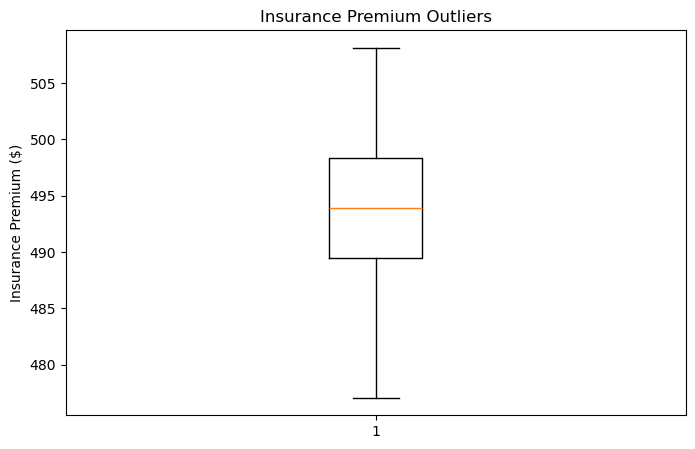

In [8]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Insurance Premium ($)"])
plt.title("Insurance Premium Outliers")
plt.ylabel("Insurance Premium ($)")
plt.show()

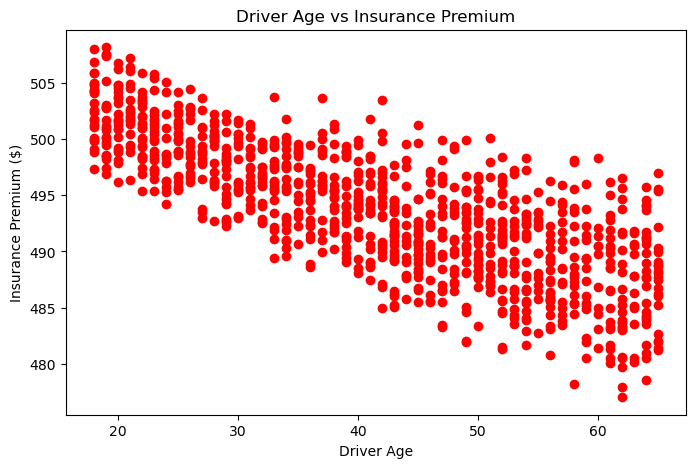

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["Driver Age"],df["Insurance Premium ($)"],color='red')
plt.xlabel("Driver Age")
plt.ylabel("Insurance Premium ($)")
plt.title("Driver Age vs Insurance Premium")
plt.show()

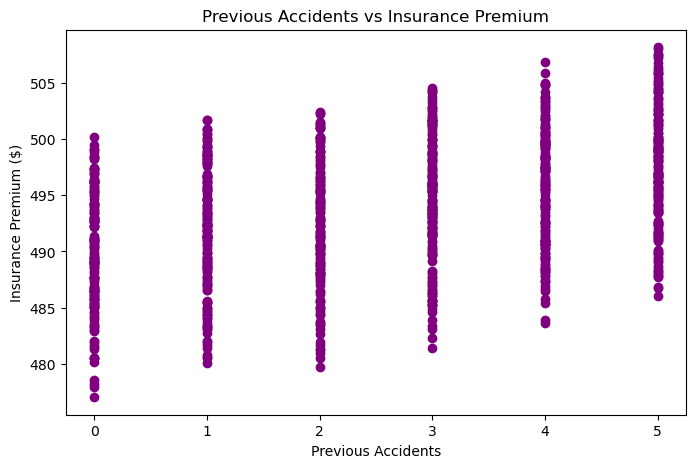

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["Previous Accidents"],df["Insurance Premium ($)"],color='purple')
plt.xlabel("Previous Accidents")
plt.ylabel("Insurance Premium ($)")
plt.title("Previous Accidents vs Insurance Premium")
plt.show()

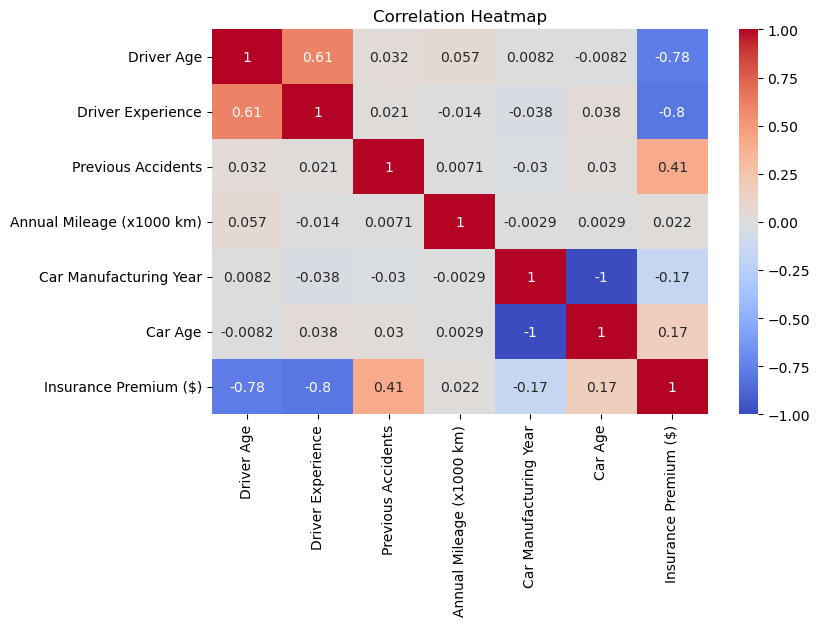

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X=df.drop("Insurance Premium ($)",axis=1)
y=df["Insurance Premium ($)"]

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred=model.predict(X_test)

In [16]:
r2 = r2_score(y_test,y_pred)
print("R2 Score:",r2)
print("R2 Score Percentage:",r2*100,"%")

R2 Score: 1.0
R2 Score Percentage: 100.0 %


In [17]:
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

Mean Squared Error: 2.6334070282449903e-27


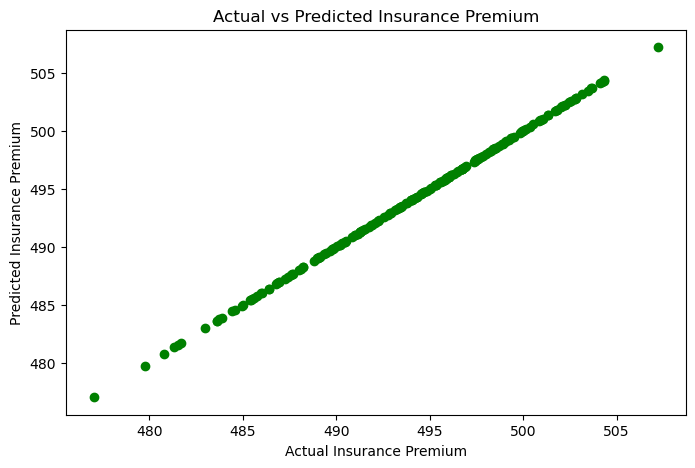

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,color='green')
plt.xlabel("Actual Insurance Premium")
plt.ylabel("Predicted Insurance Premium")
plt.title("Actual vs Predicted Insurance Premium")
plt.show()

In [21]:
joblib.dump(model,"car_insurance_premium_model.pkl")
print("Model saved!")

Model saved!
